# Lecture 3: Abstraction Under Translation


In the first notebook on causal abstraction theory, we learned about **constructive abstraction**: a high-level causal model can be implemented by a low-level system when high-level variables realize the same causal role as sets of low-level variables. 

In this sequel notebook, we introduce **abstraction under translation**. This extension of the theory allows for the low-level variable space to be **translated** into a different but causally equivalent carving, and then these new translated variables are clustered and aligned with high-level causal variables.
This is necessary when the original low-level model has variables that entangle latent factors, e.g., high-level variables that can only be aligned to the dimensions of a rotated coordinate system for activation space.  

This is essential for mechanistic interpretability. 
The computation graph of a neural network is defined over vectors represented in the standard axis-aligned coordinate system, but there is definitive and overwhelming evidence that the standard coordinate system should not be assumed by default. 
Indeed, this is precisely the motivation behind the distributed alignment search method from the third notebook in this sequence, which learns an alternative set of orthogonal basis vectors that correspond to a high-level causal variable.

### ✍ Learning goals

By the end of this lesson, we want the following to feel concrete.

**Part 1 — Translation between causal models**
* **Translation as recarving**: understand a translation as a bijection on variable settings that changes coordinates without changing the underlying causal story
* **Translation is an exact transformation**: verify the commutative equation
  $$\tau(\mathsf{Run}(\mathcal{L}_i)) = \mathsf{Run}(\mathcal{H}_{\omega(i)})$$
  on a worked example
* **Pulled-back interventions**: see why a simple hard intervention in the translated model can correspond to a more complex interventional in the original model
* **Abstraction-under-translation**: connect this notebook to the previous one, where we studied constructive abstraction directly

**Part 2 — DAS as translation discovery**
* **DAS learns a translation**: the rotation matrix $\mathbf{R}$ defines a bijective transformation on activation space that plays the role of $\tau$
* **Interchange in rotated space**: swapping a subspace in the rotated basis corresponds to a distributed perturbation in the original neuron basis — the neural analogue of pulled-back interventionals
* **IIA measures abstraction quality**: high interchange intervention accuracy means the constructive abstraction equation approximately holds under the learned translation

In [1]:
from IPython.display import clear_output
import plotly.io as pio

try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    pio.renderers.default = "colab"
    !git clone https://github.com/cs221m/cs221m-course.git
    %cd cs221m-course
    !uv sync
else:
    pio.renderers.default = "plotly_mimetype+png"
    !uv sync
    !plotly_get_chrome -y

clear_output()

Note: if the cell below fails, then re-install `causalab` with `pip install -e causalab`.

In [2]:
import random
import itertools
import numpy as np

from causalab.causal.causal_model import CausalModel
from causalab.causal.trace import Mechanism, input_var
from causalab.causal.causal_viz import print_structure, print_setting

# Set random seed for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

## 1️⃣ Recap: from constructive abstraction to translation

In Lecture 2, we worked with an alignment $(\Pi, \pi)$ that directly mapped high-level variables to sets of low-level variables. That works when the low-level model already exposes the right atomic units.
But this theory is not sufficient for the purposes of mechanistic interpretability, because we do not start with the right low-level model!

We define **abstraction-under-translation** to allow for a transformation of the low-level model:
1. first **translate** the low-level variable space into a new carving
2. then apply the familiar idea of **constructive abstraction**

Formally, if $\tau(\mathcal{L})$ is a translation of $\mathcal{L}$ and $\mathcal{H}$ is a constructive abstraction of $\tau(\mathcal{L})$, then $\mathcal{H}$ is an **abstraction-under-translation** of $\mathcal{L}$.


In this notebook we will focus on the **translation** part first, using a worked circuit example.


### The running example

We will compare two causal models.

The first model, $\mathcal{M}$, is a hierarchical equality circuit:

- $A_1, A_2, A_3, A_4$ are binary inputs
- $E_1 = (A_1 = A_2)$
- $E_2 = (A_3 = A_4)$
- $C = (E_1 = E_2)$

The second model, $\mathcal{M}^*$, uses a different intermediate carving:

- $D_1 = (A_1 = A_2)$
- $D_2 = (A_1 = A_2) = (A_3 = A_4)$
- $C = D_2$

The two models have the same input-output behavior, but their internal variables are arranged differently.


In [3]:
def eq(a, b):
    """Equality check on binary values: 1 when equal, 0 otherwise."""
    return int(a == b)

binary = [0, 1]

def project_trace(trace, variables):
    return {var: trace[var] for var in variables}

def all_binary_inputs():
    for bits in itertools.product(binary, repeat=4):
        yield {"A1": bits[0], "A2": bits[1], "A3": bits[2], "A4": bits[3]}


## 2️⃣ The high-level algorithm $\mathcal{M}$

We start with the same style of causal model used in the previous notebook: a dictionary of values, a dictionary of mechanisms, and a `CausalModel` object.

As before, `raw_input` and `raw_output` are infrastructure variables that give us stable names for the overall input and output of the computation.


In [4]:
# Note: we use 0/1 integers rather than True/False booleans (as in Lecture 2)
# so that values are directly compatible with the MLP's numerical computation.
M_values = {
    "A1": binary,
    "A2": binary,
    "A3": binary,
    "A4": binary,
    "E1": binary,
    "E2": binary,
    "C": binary,
    "raw_input": [None],
    "raw_output": binary,
}

M_mechanisms = {
    "A1": input_var(binary),
    "A2": input_var(binary),
    "A3": input_var(binary),
    "A4": input_var(binary),
    "E1": Mechanism(parents=["A1", "A2"], compute=lambda t: eq(t["A1"], t["A2"])),
    "E2": Mechanism(parents=["A3", "A4"], compute=lambda t: eq(t["A3"], t["A4"])),
    "C": Mechanism(parents=["E1", "E2"], compute=lambda t: eq(t["E1"], t["E2"])),
    "raw_input": Mechanism(
        parents=["A1", "A2", "A3", "A4"],
        compute=lambda t: (t["A1"], t["A2"], t["A3"], t["A4"]),
    ),
    "raw_output": Mechanism(parents=["C"], compute=lambda t: t["C"]),
}

M_pos = {
    "A1": (0.5, 0),
    "A2": (2.0, 0),
    "A3": (3.5, 0),
    "A4": (5.0, 0),
    "E1": (1.25, 1.5),
    "E2": (4.25, 1.5),
    "C": (2.75, 2.75),
}

M_model = CausalModel(M_mechanisms, M_values, print_pos=M_pos, id="M")
print("Variables:", M_model.variables)
print("Inputs:", M_model.inputs)
print("Outputs:", M_model.outputs)

Variables: ['A1', 'A2', 'A3', 'A4', 'E1', 'E2', 'C', 'raw_input', 'raw_output']
Inputs: ['A1', 'A2', 'A3', 'A4']
Outputs: ['raw_input', 'raw_output']


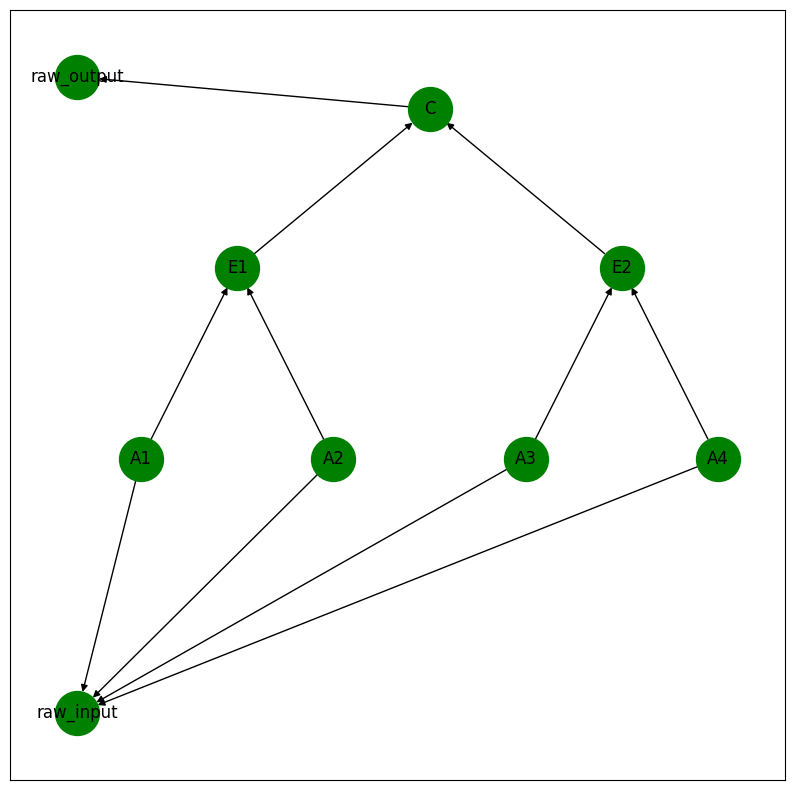

Timesteps: {'A1': 0, 'A2': 0, 'A3': 0, 'A4': 0, 'E1': 1, 'raw_input': 3, 'E2': 1, 'C': 2, 'raw_output': 3}


In [5]:
print_structure(M_model)
print("Timesteps:", M_model.timesteps)


### Running $\mathcal{M}$ on a concrete input

For input $(1,1,0,0)$, each pair agrees, so $E_1 = 1$, $E_2 = 1$, and the final equality check also returns $1$.


In [6]:
trace_M = M_model.new_trace({"A1": 1, "A2": 1, "A3": 0, "A4": 0})

print("Input:", trace_M["raw_input"])
print("E1 =", trace_M["E1"])
print("E2 =", trace_M["E2"])
print("C  =", trace_M["C"])


Input: (1, 1, 0, 0)
E1 = 1
E2 = 1
C  = 1


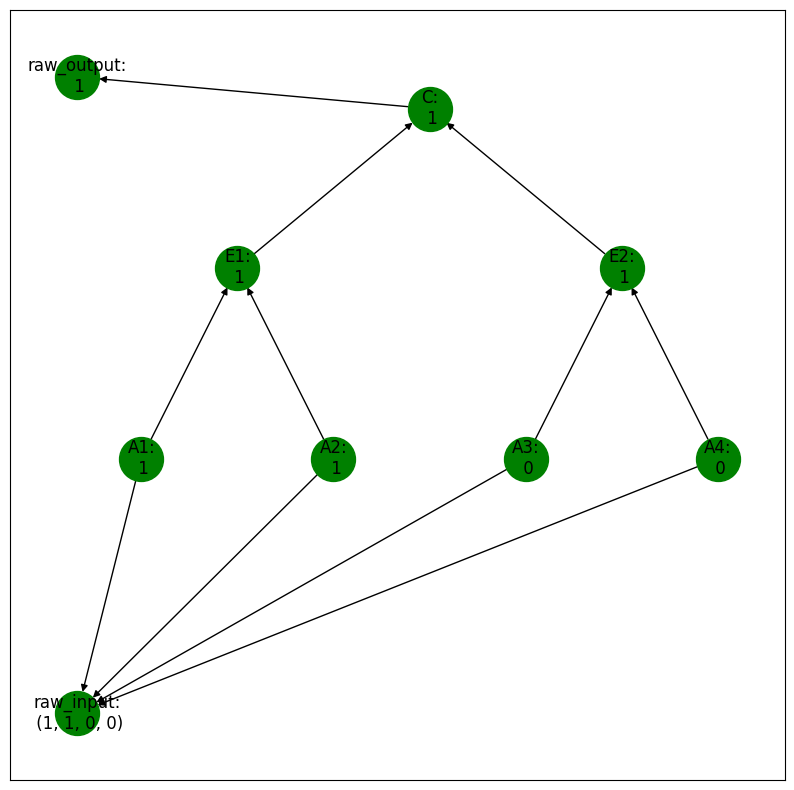

In [ ]:
print_setting(M_model, trace_M.to_dict())

### 🧠 Takeaways

- $\mathcal{M}$ is the same sort of causal model we used in Lecture 2
- the internal variables $E_1$ and $E_2$ are the natural intermediate computations
- a hard intervention on $\mathcal{M}$ would be simple: set one of these variables directly and recompute downstream


## 3️⃣ A different carving: the circuit $\mathcal{M}^*$

Now we build the alternative model $\mathcal{M}^*$.

The crucial change is that the second intermediate variable is no longer “the equality relation on the second pair.” Instead, it is a more entangled quantity:
$$
D_2 = (A_1 = A_2) = (A_3 = A_4).
$$

So $D_2$ already contains the final comparison.


In [8]:
M_star_values = {
    "A1": binary,
    "A2": binary,
    "A3": binary,
    "A4": binary,
    "D1": binary,
    "D2": binary,
    "C": binary,
    "raw_input": [None],
    "raw_output": binary,
}

M_star_mechanisms = {
    "A1": input_var(binary),
    "A2": input_var(binary),
    "A3": input_var(binary),
    "A4": input_var(binary),
    "D1": Mechanism(parents=["A1", "A2"], compute=lambda t: eq(t["A1"], t["A2"])),
    "D2": Mechanism(
        parents=["A1", "A2", "A3", "A4"],
        compute=lambda t: eq(eq(t["A1"], t["A2"]), eq(t["A3"], t["A4"])),
    ),
    "C": Mechanism(parents=["D2"], compute=lambda t: t["D2"]),
    "raw_input": Mechanism(
        parents=["A1", "A2", "A3", "A4"],
        compute=lambda t: (t["A1"], t["A2"], t["A3"], t["A4"]),
    ),
    "raw_output": Mechanism(parents=["C"], compute=lambda t: t["C"]),
}

M_star_pos = {
    "A1": (0.5, 0),
    "A2": (2.0, 0),
    "A3": (3.5, 0),
    "A4": (5.0, 0),
    "D1": (1.75, 1.5),
    "D2": (3.75, 1.5),
    "C": (2.75, 2.75),
}

M_star_model = CausalModel(M_star_mechanisms, M_star_values, print_pos=M_star_pos, id="M_star")
print("Variables:", M_star_model.variables)


Variables: ['A1', 'A2', 'A3', 'A4', 'D2', 'C', 'D1', 'raw_input', 'raw_output']


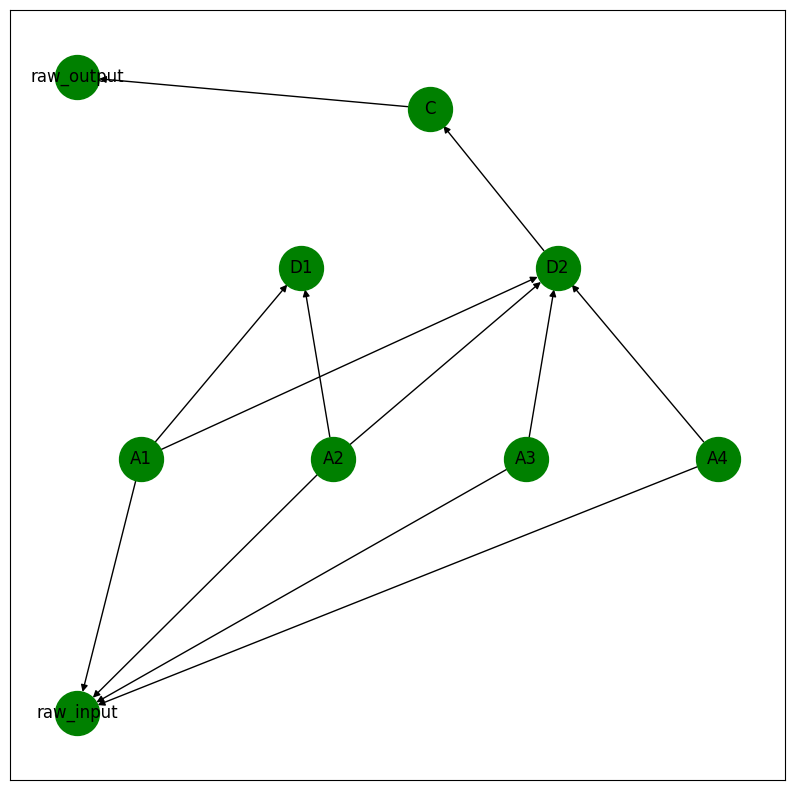

In [9]:
print_structure(M_star_model)

### Same input-output behavior, different internals

The two circuits compute the same output on every input, but the internal variables do different jobs.

For example, when the input is $(1,0,1,0)$:

- in $\mathcal{M}$, we get $E_1 = 0$, $E_2 = 0$, and then $C = 1$
- in $\mathcal{M}^*$, we get $D_1 = 0$, $D_2 = 1$, and then $C = 1$

So $D_2$ is not playing the same role as $E_2$.


In [10]:
sample_input = {"A1": 1, "A2": 0, "A3": 1, "A4": 0}

trace_M_sample = M_model.new_trace(sample_input)
trace_M_star_sample = M_star_model.new_trace(sample_input)

print("Input:", tuple(sample_input[k] for k in ["A1", "A2", "A3", "A4"]))
print("M trace     :", project_trace(trace_M_sample, ["A1", "A2", "A3", "A4", "E1", "E2", "C"]))
print("M* trace    :", project_trace(trace_M_star_sample, ["A1", "A2", "A3", "A4", "D1", "D2", "C"]))

Input: (1, 0, 1, 0)
M trace     : {'A1': 1, 'A2': 0, 'A3': 1, 'A4': 0, 'E1': 0, 'E2': 0, 'C': 1}
M* trace    : {'A1': 1, 'A2': 0, 'A3': 1, 'A4': 0, 'D1': 0, 'D2': 1, 'C': 1}


In [11]:
matches = 0
rows = []

for setting in all_binary_inputs():
    t_M = M_model.new_trace(setting)
    t_M_star = M_star_model.new_trace(setting)

    rows.append(
        (
            tuple(setting[k] for k in ["A1", "A2", "A3", "A4"]),
            (t_M["E1"], t_M["E2"], t_M["C"]),
            (t_M_star["D1"], t_M_star["D2"], t_M_star["C"]),
        )
    )

    if t_M["C"] == t_M_star["C"]:
        matches += 1

print(f"Output agreement on all 16 inputs: {matches}/16")
print()
print("A few rows:")
for inp, m_vals, m_star_vals in rows[:6]:
    print(f"  input={inp}   M(E1,E2,C)={m_vals}   M*(D1,D2,C)={m_star_vals}")

Output agreement on all 16 inputs: 16/16

A few rows:
  input=(0, 0, 0, 0)   M(E1,E2,C)=(1, 1, 1)   M*(D1,D2,C)=(1, 1, 1)
  input=(0, 0, 0, 1)   M(E1,E2,C)=(1, 0, 0)   M*(D1,D2,C)=(1, 0, 0)
  input=(0, 0, 1, 0)   M(E1,E2,C)=(1, 0, 0)   M*(D1,D2,C)=(1, 0, 0)
  input=(0, 0, 1, 1)   M(E1,E2,C)=(1, 1, 1)   M*(D1,D2,C)=(1, 1, 1)
  input=(0, 1, 0, 0)   M(E1,E2,C)=(0, 1, 0)   M*(D1,D2,C)=(0, 0, 0)
  input=(0, 1, 0, 1)   M(E1,E2,C)=(0, 0, 1)   M*(D1,D2,C)=(0, 1, 1)


## 4️⃣ Translation as a change of variables

The translation is the bijection
$$
(a_1,a_2,a_3,a_4,d_1,d_2,c)
\overset{\tau}{\mapsto}
(a_1,a_2,a_3,a_4,d_1, (d_1 = d_2), c).
$$

Reading the right-hand side as a state of $\mathcal{M}$, this means:

- $E_1 = D_1$
- $E_2 = (D_1 = D_2)$
- $C = C$

So the translation does **not** compress the state space. It simply introduces a different coordinate system for the same seven binary variables.


In [12]:
def tau_star_to_M(trace_star):
    """Translate a full setting of M* variables into the M variable space."""
    return {
        "A1": trace_star["A1"],
        "A2": trace_star["A2"],
        "A3": trace_star["A3"],
        "A4": trace_star["A4"],
        "E1": trace_star["D1"],
        "E2": eq(trace_star["D1"], trace_star["D2"]),
        "C": trace_star["C"],
    }

def tau_inverse_from_M(setting_M):
    """Inverse translation back into the M* variable space."""
    return {
        "A1": setting_M["A1"],
        "A2": setting_M["A2"],
        "A3": setting_M["A3"],
        "A4": setting_M["A4"],
        "D1": setting_M["E1"],
        "D2": eq(setting_M["E1"], setting_M["E2"]),
        "C": setting_M["C"],
    }

### Checking that $\tau$ is really a bijection

A translation is defined on the full space of variable settings, not just on the states that happen to arise under normal runs. So we check the inverse formulas on **all** binary settings of the two variable spaces.


In [ ]:
all_M_star_states = []
for a1, a2, a3, a4, d1, d2, c in itertools.product(binary, repeat=7):
    all_M_star_states.append(
        {"A1": a1, "A2": a2, "A3": a3, "A4": a4, "D1": d1, "D2": d2, "C": c}
    )

all_M_states = []
for a1, a2, a3, a4, e1, e2, c in itertools.product(binary, repeat=7):
    all_M_states.append(
        {"A1": a1, "A2": a2, "A3": a3, "A4": a4, "E1": e1, "E2": e2, "C": c}
    )

left_inverse_ok = all(
    tau_inverse_from_M(tau_star_to_M(s)) == s
    for s in all_M_star_states
)

right_inverse_ok = all(
    tau_star_to_M(tau_inverse_from_M(s)) == s
    for s in all_M_states
)

print("tau_inverse(tau(s)) = s on all M* states:", left_inverse_ok)
print("tau(tau_inverse(s)) = s on all M states :", right_inverse_ok)

tau_inverse(tau(s)) = s on all M* states: True
tau(tau_inverse(s)) = s on all M states : True


### Checking the translation on actual runs

Now we restrict attention back to normal executions of the two models. If $\tau$ really translates $\mathcal{M}^*$ into $\mathcal{M}$, then for every input setting $i$ we should have
$$
\tau(\mathsf{Run}(\mathcal{M}^*(i))) = \mathsf{Run}(\mathcal{M}(i)).
$$


In [14]:
translated_matches = 0

for setting in all_binary_inputs():
    t_M = M_model.new_trace(setting)
    t_M_star = M_star_model.new_trace(setting)

    translated = tau_star_to_M(t_M_star)
    target = project_trace(t_M, ["A1", "A2", "A3", "A4", "E1", "E2", "C"])

    if translated == target:
        translated_matches += 1

print(f"tau(Run(M*(i))) = Run(M(i)) on {translated_matches}/16 inputs")

tau(Run(M*(i))) = Run(M(i)) on 16/16 inputs


In [15]:
example = {"A1": 1, "A2": 0, "A3": 1, "A4": 1}

t_star = M_star_model.new_trace(example)
t_high = M_model.new_trace(example)

print("M* trace          :", project_trace(t_star, ["A1", "A2", "A3", "A4", "D1", "D2", "C"]))
print("tau(M* trace)     :", tau_star_to_M(t_star))
print("M trace           :", project_trace(t_high, ["A1", "A2", "A3", "A4", "E1", "E2", "C"]))

M* trace          : {'A1': 1, 'A2': 0, 'A3': 1, 'A4': 1, 'D1': 0, 'D2': 0, 'C': 0}
tau(M* trace)     : {'A1': 1, 'A2': 0, 'A3': 1, 'A4': 1, 'E1': 0, 'E2': 1, 'C': 0}
M trace           : {'A1': 1, 'A2': 0, 'A3': 1, 'A4': 1, 'E1': 0, 'E2': 1, 'C': 0}


### What just happened?

The two models are not related by grouping variables into macrovariables. Instead, they use **different internal coordinates**.

That is the new ingredient in this notebook:

- Lecture 2 focused on moving from low-level variables to high-level variables by **clustering**
- this lecture adds a prior step where we first **re-express** the low-level system in a new variable space


## 5️⃣ Pulling back a hard intervention through the translation

Exact transformation is not just about ordinary runs. It is about **counterfactual runs** too.

So we now ask the key question:

If we do a simple hard intervention on the translated model $\mathcal{M}$, what operation on the original model $\mathcal{M}^*$ plays the same causal role?

We will work with the hard intervention $E_1 \leftarrow e$ for $e \in \{0,1\}$.

At the level of $\mathcal{M}$, this is simple: break the arrow into $E_1$, set $E_1$ to a constant, and let the rest of the computation continue.


In [16]:
def make_M_do_E1(value):
    mechanisms = {
        "A1": input_var(binary),
        "A2": input_var(binary),
        "A3": input_var(binary),
        "A4": input_var(binary),
        "E1": Mechanism(parents=["A1"], compute=lambda t, v=value: v),
        "E2": Mechanism(parents=["A3", "A4"], compute=lambda t: eq(t["A3"], t["A4"])),
        "C": Mechanism(parents=["E1", "E2"], compute=lambda t: eq(t["E1"], t["E2"])),
        "raw_input": Mechanism(
            parents=["A1", "A2", "A3", "A4"],
            compute=lambda t: (t["A1"], t["A2"], t["A3"], t["A4"]),
        ),
        "raw_output": Mechanism(parents=["C"], compute=lambda t: t["C"]),
    }
    return CausalModel(mechanisms, M_values, print_pos=M_pos, id=f"M_do_E1_{value}")

def make_M_star_pullback_E1(value):
    """The pulled-back interventional on M* corresponding to E1 <- value upstairs."""
    mechanisms = {
        "A1": input_var(binary),
        "A2": input_var(binary),
        "A3": input_var(binary),
        "A4": input_var(binary),
        "D1": Mechanism(parents=["A1"], compute=lambda t, v=value: v),
        "D2": Mechanism(
            parents=["A3", "A4"],
            compute=lambda t, v=value: eq(v, eq(t["A3"], t["A4"])),
        ),
        "C": Mechanism(parents=["D2"], compute=lambda t: t["D2"]),
        "raw_input": Mechanism(
            parents=["A1", "A2", "A3", "A4"],
            compute=lambda t: (t["A1"], t["A2"], t["A3"], t["A4"]),
        ),
        "raw_output": Mechanism(parents=["C"], compute=lambda t: t["C"]),
    }
    return CausalModel(mechanisms, M_star_values, print_pos=M_star_pos, id=f"M_star_pullback_E1_{value}")

The low-level interventional is already more interesting.

To realize $E_1 \leftarrow e$ downstairs in $\mathcal{M}^*$ we need to edit **two** mechanisms:

- set $D_1 := e$
- redefine $D_2$ so that it now computes
  $$
  D_2 = (e = (A_3 = A_4))
  $$

This ensures that after translation we recover

- $E_1 = e$
- $E_2 = (A_3 = A_4)$
- $C = (e = (A_3 = A_4))$

So a **hard intervention** on the original model becomes a **multi-mechanism interventional** on the translated model.


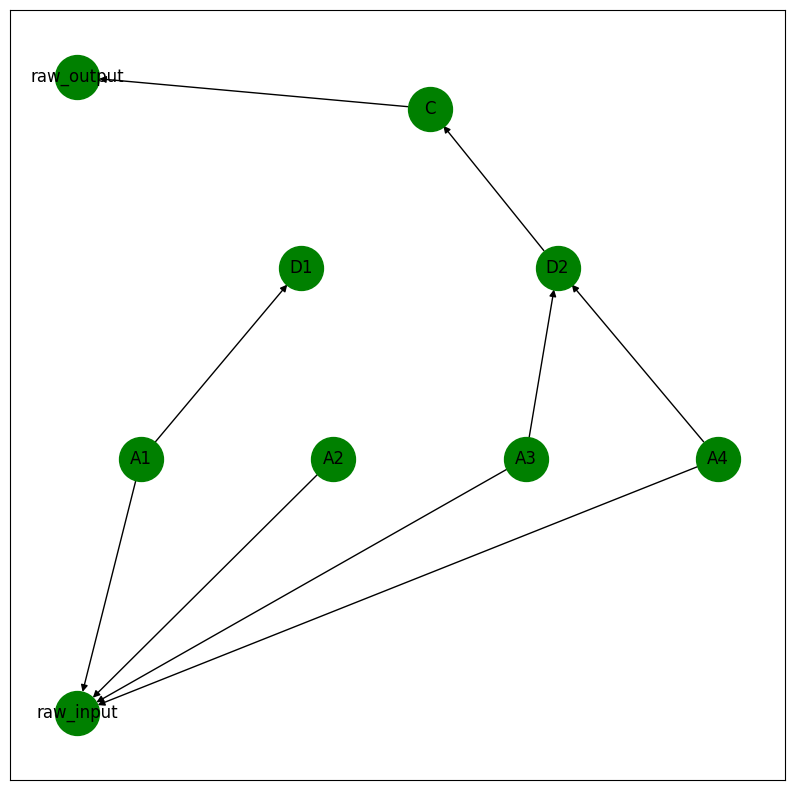

In [17]:
M_star_pullback_1 = make_M_star_pullback_E1(1)
print_structure(M_star_pullback_1)

Notice the new causal pattern:

- $D_1$ has become a constant
- $D_2$ now depends only on $A_3$ and $A_4$

This is exactly what a “pulled-back” intervention looks like.


In [18]:
setting = {"A1": 0, "A2": 1, "A3": 1, "A4": 1}

high_do = make_M_do_E1(1).new_trace(setting)
low_pullback = make_M_star_pullback_E1(1).new_trace(setting)

print("Input:", tuple(setting[k] for k in ["A1", "A2", "A3", "A4"]))
print()
print("High-level E1 <- 1 trace:")
print(project_trace(high_do, ["A1", "A2", "A3", "A4", "E1", "E2", "C"]))
print()
print("Low-level pulled-back trace in M*:")
print(project_trace(low_pullback, ["A1", "A2", "A3", "A4", "D1", "D2", "C"]))
print()
print("Translated low-level trace:")
print(tau_star_to_M(low_pullback))

Input: (0, 1, 1, 1)

High-level E1 <- 1 trace:
{'A1': 0, 'A2': 1, 'A3': 1, 'A4': 1, 'E1': 1, 'E2': 1, 'C': 1}

Low-level pulled-back trace in M*:
{'A1': 0, 'A2': 1, 'A3': 1, 'A4': 1, 'D1': 1, 'D2': 1, 'C': 1}

Translated low-level trace:
{'A1': 0, 'A2': 1, 'A3': 1, 'A4': 1, 'E1': 1, 'E2': 1, 'C': 1}


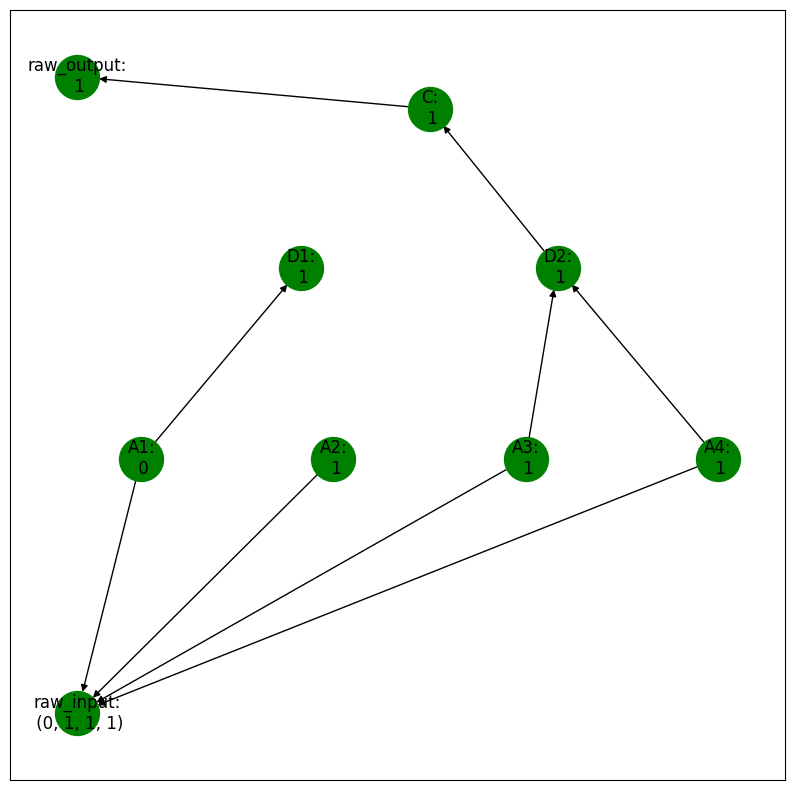

In [19]:
print_setting(M_star_pullback_1, low_pullback.to_dict())

### Verifying the exact-transformation equation for this intervention family

Let $i_{E_1 \leftarrow b}$ name the pulled-back interventional on $\mathcal{M}^*$, and let
$$
\omega_\tau(i_{E_1 \leftarrow b}) = (E_1 \leftarrow b).
$$

Then the exact-transformation requirement says
$$
\tau(\mathsf{Run}(\mathcal{M}^*_{i_{E_1 \leftarrow b}}(x)))
=
\mathsf{Run}(\mathcal{M}_{E_1 \leftarrow b}(x))
$$
for every input $x$.


In [20]:
def check_pullback_E1(value):
    M_do = make_M_do_E1(value)
    M_star_pull = make_M_star_pullback_E1(value)

    for setting in all_binary_inputs():
        low = M_star_pull.new_trace(setting)
        high = M_do.new_trace(setting)

        translated_low = tau_star_to_M(low)
        high_trace = project_trace(high, ["A1", "A2", "A3", "A4", "E1", "E2", "C"])

        if translated_low != high_trace:
            return False, setting, translated_low, high_trace

    return True, None, None, None

for b in binary:
    ok, bad_setting, low_trace, high_trace = check_pullback_E1(b)
    print(f"omega_tau(i*_E1<-{b}) = E1<-{b}  ->  commutation holds: {ok}")

omega_tau(i*_E1<-0) = E1<-0  ->  commutation holds: True
omega_tau(i*_E1<-1) = E1<-1  ->  commutation holds: True


That is the core point. The intervention map $\omega_\tau$ does not have to send hard interventions to hard interventions.

This is why translations are powerful: they let us treat two different carvings of the same system as causally equivalent even when the matching manipulations look quite different.


## 6️⃣ From translation to abstraction-under-translation

We can now state the idea that connects this notebook to Lecture 2.

A model $\mathcal{H}$ is an **abstraction-under-translation** of a model $\mathcal{L}$ if:

1. there is a translation $\tau(\mathcal{L})$ of $\mathcal{L}$ into a new variable space, and
2. $\mathcal{H}$ is a **constructive abstraction** of that translated model

So the pipeline is:

$$
\mathcal{L}
\xrightarrow{\text{translation }\tau}
\tau(\mathcal{L})
\xrightarrow{\text{constructive abstraction}}
\mathcal{H}
$$

In this notebook we isolated the first arrow and made it concrete.


### 🧠 Takeaways

- a **translation** is a bijection on variable settings, not a compression
- in our examples, $\mathcal{M}$ and $\mathcal{M}^*$ have the same behavior, but different internal coordinates
- the map
  $$
  (a_1,a_2,a_3,a_4,d_1,d_2,c) \mapsto (a_1,a_2,a_3,a_4,d_1,(d_1 = d_2),c)
  $$
  translates $\mathcal{M}^*$ into $\mathcal{M}$
- a simple hard intervention in the translated model can pull back to a more complex **interventional** in the original model
- **abstraction-under-translation** is the composition of translation and constructive abstraction


## 7️⃣ Distributed Alignment Search as Learning a Translation

The example above showed that translations exist between equivalent models: a bijection $\tau$ recarves the variable space of $\mathcal{M}^*$ into $\mathcal{M}$, preserving all causal structure. But in that example, we *knew* $\tau$ upfront.

In practice, we don't. When a neural network solves hierarchical equality, its hidden activations might encode $E_1$ and $E_2$ *somewhere* — but it could be in an arbitrary, entangled coordinate system, like $\mathcal{M}^*$'s $(D_1, D_2)$. We need to **learn** the translation.

**Distributed Alignment Search (DAS)** does exactly this. DAS learns a low-rank orthogonal matrix $\mathbf{R} \in \mathbb{R}^{k \times d}$ that projects onto a subspace with the causal role of a high-level variable. 

We can use this low-rank matrix to define a bijective transformation on the whole space where we simply store the residual information not captured in the low-dimensional subspace. Starting with an activation vector $h$ we can define the forward transformation as:
$$f = (\mathbf{R}h,\; h - \mathbf{R}^T(\mathbf{R}h))$$
where the first entry of $f$ is the projection of $h$ onto the subspace defined by $\mathbf{R}$ and the second entry in $h'$ is the residual. The backward transformation is:
$$h = \mathbf{R}^Tf_{1} + f_2$$
This bijective function on the activation space of $h$ can in turn be used to define a full translation $\tau$ where low-level variables that aren't defining $h$ remain unchanged.

We will now train an MLP on hierarchical equality and use DAS to discover this rotation.

### Why random embeddings?

The MLP input is constructed from **fresh random vectors on every example**. Positions that share the same binary value receive the same vector; positions with different values receive independent random vectors. This forces the network to learn a relational equality detector — it cannot memorize specific letter embeddings, because it never sees the same vectors twice. The only stable signal is the geometric relationship (identity vs. difference) between positions within each pair.

In [21]:
import torch
from torch.utils.data import DataLoader
from datasets import Dataset
from tqdm import tqdm, trange

from pyvene.models.mlp.modelings_mlp import MLPConfig
from pyvene import create_mlp_classifier
from pyvene import (
    IntervenableModel,
    RotatedSpaceIntervention,
    RepresentationConfig,
    IntervenableConfig,
)

torch.manual_seed(seed)

# --- Embedding helpers ---
embedding_dim = 4

def randvec(n=4, lower=-1, upper=1):
    """Sample a random vector uniformly in [lower, upper]^n."""
    return np.array([round(random.uniform(lower, upper), 2) for _ in range(n)])

def make_input_tensor(trace):
    """Map a M_model trace to a 16-dim input vector.
    
    Uses fresh random entity vectors each call. Positions whose binary
    values are equal get the SAME vector; different values get DIFFERENT
    vectors. Cross-pair positions always get distinct vectors.
    
    This means the MLP can only detect equality by comparing positions
    within a pair — matching the causal structure of M_model.
    """
    e = [randvec(embedding_dim) for _ in range(4)]
    
    vecs = [None] * 4
    vecs[0] = e[0]  # A1 → entity 0
    vecs[1] = e[0] if trace["A1"] == trace["A2"] else e[1]  # A2
    vecs[2] = e[2]  # A3 → entity 2 (distinct from pair 1)
    vecs[3] = e[2] if trace["A3"] == trace["A4"] else e[3]  # A4
    
    return torch.tensor(np.concatenate(vecs), dtype=torch.float32)

print(f"Embedding dim: {embedding_dim}, MLP input dim: {embedding_dim * 4}")
print("Each example uses 4 fresh random vectors, with within-pair equality matching E1/E2.")

Embedding dim: 4, MLP input dim: 16
Each example uses 4 fresh random vectors, with within-pair equality matching E1/E2.


### Training an MLP on hierarchical equality

For each training example, we generate 4 fresh random entity vectors ($A, B, C, D$) and construct the MLP input by assigning them to positions $A_1$–$A_4$ according to the binary equality pattern:

| Pattern | Positions | $E_1$ | $E_2$ |
|---------|-----------|-------|-------|
| $ABCD$  | all different | 0 | 0 |
| $AABB$  | pairs match | 1 | 1 |
| $AACD$  | first pair matches | 1 | 0 |
| $ABCC$  | second pair matches | 0 | 1 |

Crucially, cross-pair positions always get **distinct** vectors, so the MLP can only detect equality by comparing positions within each pair.

In [22]:
# --- Generate training data using M_model ---
def generate_factual_data(causal_model, n):
    """Generate factual training data with per-example random embeddings."""
    X_list, y_list = [], []
    for _ in range(n):
        trace = causal_model.sample_input()
        X_list.append(make_input_tensor(trace))
        y_list.append(trace["C"])
    return torch.stack(X_list), torch.tensor(y_list, dtype=torch.long)

n_train = 1048576
batch_size = 1024

X_train, y_train = generate_factual_data(M_model, n_train)

print(f"Training data: {X_train.shape[0]} examples, input dim = {X_train.shape[1]}")
print(f"Label balance: {(y_train == 1).sum().item()} positive, {(y_train == 0).sum().item()} negative")

Training data: 1048576 examples, input dim = 16
Label balance: 524937 positive, 523639 negative


In [23]:
# --- Train MLP with custom PyTorch loop ---
h_dim = 16
mlp_config = MLPConfig(
    h_dim=h_dim, n_layer=3, pdrop=0.0,
    include_bias=True, num_classes=2,
    squeeze_output=False, input_dim=embedding_dim * 4
)
_, _, mlp = create_mlp_classifier(mlp_config)

# Kaiming init for gradient flow through ReLU layers
for name, p in mlp.named_parameters():
    if 'weight' in name and p.dim() >= 2:
        torch.nn.init.kaiming_normal_(p, nonlinearity='relu')
    elif 'bias' in name:
        torch.nn.init.zeros_(p)

mlp.to("cuda")
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.01)

n_epochs = 3
for epoch in range(n_epochs):
    correct, total = 0, 0
    perm = torch.randperm(X_train.shape[0])
    for start in range(0, X_train.shape[0], batch_size):
        idx = perm[start:start + batch_size]
        xb = X_train[idx].to("cuda")
        yb = y_train[idx].to("cuda")
        
        loss, logits = mlp(inputs_embeds=xb, labels=yb)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.shape[0]
    
    print(f"Epoch {epoch+1}/{n_epochs}  accuracy: {correct/total:.4f}")

with torch.no_grad():
    logits_check = mlp(inputs_embeds=X_train[:1000].to("cuda"))[0]
    print(f"\nLogit range: [{logits_check.min().item():.1f}, {logits_check.max().item():.1f}]")

loaded model


Epoch 1/3  accuracy: 0.9510
Epoch 2/3  accuracy: 0.9988
Epoch 3/3  accuracy: 0.9992

Logit range: [-56.1, 60.7]


In [23]:
# --- Test on fresh data ---
n_test = 10000
X_test, y_test = generate_factual_data(M_model, n_test)
X_test, y_test = X_test.to("cuda"), y_test.to("cuda")

mlp.eval()
with torch.no_grad():
    test_logits = mlp(inputs_embeds=X_test)[0]
    test_preds = test_logits.argmax(1)
    test_acc = (test_preds == y_test).float().mean().item()

print(f"Test accuracy: {test_acc:.4f}")
print("\nThe MLP solves the task — but we don't yet know how its hidden layer encodes E₁ and E₂.")

Test accuracy: 0.9994

The MLP solves the task — but we don't yet know how its hidden layer encodes E₁ and E₂.


In [24]:
# --- Counterfactual dataset using M_model ---

def generate_counterfactual_data(causal_model, n, intervention_id=2):
    """Generate counterfactual data for DAS training or evaluation.
    
    Each example samples a base input and source input(s), then computes the
    counterfactual label under interchange of the specified variable(s).
    
    Args:
        intervention_id: which variable(s) to interchange.
            0 = E1 only, 1 = E2 only, 2 = both E1 and E2.
    """
    examples = []
    
    for _ in range(n):
        base_trace = causal_model.sample_input()
        source1_trace = causal_model.sample_input()
        source2_trace = causal_model.sample_input()
        
        base_tensor = make_input_tensor(base_trace)
        source1_tensor = make_input_tensor(source1_trace)
        source2_tensor = make_input_tensor(source2_trace)
        
        # Compute counterfactual label based on which variables are swapped
        cf_E1 = source1_trace["E1"] if intervention_id in (0, 2) else base_trace["E1"]
        cf_E2 = source2_trace["E2"] if intervention_id in (1, 2) else base_trace["E2"]
        cf_label = eq(cf_E1, cf_E2)
        
        examples.append({
            "input_ids": base_tensor,
            "source_input_ids": torch.stack([source1_tensor, source2_tensor]),
            "labels": torch.tensor(cf_label, dtype=torch.long),
            "intervention_id": intervention_id,
        })
    
    return examples

cf_batch_size = 6400
n_cf = 1280000

train_cf_dataset = generate_counterfactual_data(M_model, n_cf, intervention_id=2)
print(f"Counterfactual training data: {len(train_cf_dataset)} examples")
print(f"Keys: {list(train_cf_dataset[0].keys())}")
iid_counts = torch.tensor([d['intervention_id'] for d in train_cf_dataset[:100]])
print(f"Intervention ID distribution: {iid_counts.unique(return_counts=True)}")

In [29]:

# --- DAS helper functions ---

def create_das_model(mlp, layer, hidden_dim, emb_dim):
    """Wrap MLP in an IntervenableModel with RotatedSpaceIntervention."""
    config = IntervenableConfig(
        model_type=type(mlp),
        representations=[
            RepresentationConfig(
                layer, "block_output", "pos", 1,
                subspace_partition=None,
                intervention_link_key=0,
            ),
            RepresentationConfig(
                layer, "block_output", "pos", 1,
                subspace_partition=None,
                intervention_link_key=0,
            ),
        ],
        intervention_types=RotatedSpaceIntervention,
    )
    return IntervenableModel(config, mlp, use_fast=True)


def run_das_forward(das_model, batch, batch_size, emb_dim):
    """Dispatch intervention based on intervention_id (0=E1, 1=E2, 2=both).
    
    Subspace partition in the rotated space:
      dims 0 : emb_dim*2  (0:8)  → E1 subspace
      dims emb_dim*2 : emb_dim*4  (8:16) → E2 subspace
    Each variable gets emb_dim*2 = 8 dimensions, partitioning the full
    16-dim rotated hidden layer into two equal halves.
    
    Source tensor mapping:
      source_input_ids[:, 0] = source1 (provides E1)
      source_input_ids[:, 1] = source2 (provides E2)
    """
    iid = batch["intervention_id"][0].item()
    
    if iid == 2:
        _, cf_out = das_model(
            {"inputs_embeds": batch["input_ids"]},
            [
                {"inputs_embeds": batch["source_input_ids"][:, 0]},
                {"inputs_embeds": batch["source_input_ids"][:, 1]},
            ],
            {"sources->base": (
                [[[0]] * batch_size, [[0]] * batch_size],
                [[[0]] * batch_size, [[0]] * batch_size],
            )},
            subspaces=[
                [[_ for _ in range(0, emb_dim * 2)]] * batch_size,
                [[_ for _ in range(emb_dim * 2, emb_dim * 4)]] * batch_size,
            ],
        )
    elif iid == 0:
        _, cf_out = das_model(
            {"inputs_embeds": batch["input_ids"]},
            [{"inputs_embeds": batch["source_input_ids"][:, 0]}, None],
            {"sources->base": (
                [[[0]] * batch_size, None],
                [[[0]] * batch_size, None],
            )},
            subspaces=[
                [[_ for _ in range(0, emb_dim * 2)]] * batch_size,
                None,
            ],
        )
    elif iid == 1:
        # E2 only: use source2 (index 1) for the E2 subspace
        _, cf_out = das_model(
            {"inputs_embeds": batch["input_ids"]},
            [None, {"inputs_embeds": batch["source_input_ids"][:, 1]}],
            {"sources->base": (
                [None, [[0]] * batch_size],
                [None, [[0]] * batch_size],
            )},
            subspaces=[
                None,
                [[_ for _ in range(emb_dim * 2, emb_dim * 4)]] * batch_size,
            ],
        )
    return cf_out


def batched_random_sampler(data, batch_size):
    """Yield indices in shuffled batch order."""
    batch_indices = list(range(int(len(data) / batch_size)))
    random.shuffle(batch_indices)
    for b_i in batch_indices:
        for i in range(b_i * batch_size, (b_i + 1) * batch_size):
            yield i


def compute_metrics(preds, labels):
    correct = (preds == labels).sum().item()
    return {"accuracy": correct / len(labels)}


def compute_loss(logits, labels):
    return torch.nn.CrossEntropyLoss()(logits, labels)

print("DAS helpers defined.")

DAS helpers defined.


### Training $\mathbf{R}$: Distributed Alignment Search

We train the rotation matrix $\mathbf{R}$ while keeping the MLP weights frozen. The only trainable parameters are the entries of the orthogonal matrix. The loss is cross-entropy between the network's counterfactual output in the rotated space and the label predicted by the causal model — if the rotation aligns the subspace with the right causal variable, swapping that subspace should reproduce the high-level counterfactual.

Note the subspace allocation: each variable gets `emb_dim * 2 = 8` dimensions out of 16 total — half the hidden layer. This is a large subspace; in practice, DAS on real language models often discovers that causal variables occupy much lower-dimensional subspaces (e.g., 1–4 dimensions out of hundreds or thousands).

In [26]:

# --- Train DAS ---
das_model = create_das_model(mlp, layer=0, hidden_dim=h_dim, emb_dim=embedding_dim)
das_model.set_device("cuda")
das_model.disable_model_gradients()

# Optimizer on rotation parameters only
optimizer_params = []
for k, v in das_model.interventions.items():
    optimizer_params += [{"params": v.rotate_layer.parameters()}]
    break  # linked interventions share the same rotation
das_optimizer = torch.optim.Adam(optimizer_params, lr=0.001)

print(f"Trainable parameters: {das_model.count_parameters()}")

das_epochs = 10
for epoch in range(das_epochs):
    das_model.model.train()
    epoch_loss, epoch_correct, epoch_total = 0, 0, 0
    
    loader = DataLoader(
        train_cf_dataset, batch_size=cf_batch_size,
        sampler=batched_random_sampler(train_cf_dataset, cf_batch_size),
    )
    
    for batch in loader:
        batch["input_ids"] = batch["input_ids"].unsqueeze(1)
        batch["source_input_ids"] = batch["source_input_ids"].unsqueeze(2)
        bs = batch["input_ids"].shape[0]
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch[k] = v.to("cuda")
        
        cf_out = run_das_forward(das_model, batch, bs, embedding_dim)
        logits = cf_out[0].squeeze(1)  # [batch, 2]
        
        labels = batch["labels"].squeeze().long()
        preds = logits.argmax(1)
        
        loss = compute_loss(logits, labels)
        
        das_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(das_model.parameters(), 1.0)
        das_optimizer.step()
        das_model.set_zero_grad()
        
        epoch_loss += loss.item()
        epoch_correct += (preds == labels).sum().item()
        epoch_total += bs
    
    iia = epoch_correct / epoch_total
    avg_loss = epoch_loss / (epoch_total / cf_batch_size)
    print(f"Epoch {epoch+1}/{das_epochs}  loss: {avg_loss:.4f}  IIA: {iia:.4f}")



In case multiple location tags are passed only the first one will be considered


Trainable parameters: 256


Epoch 1/10  loss: 7.7143  IIA: 0.6784


Epoch 2/10  loss: 1.2372  IIA: 0.8437


Epoch 3/10  loss: 0.1144  IIA: 0.9601


...

Epoch 6/10  loss: 0.0104  IIA: 0.9971


Epoch 7/10  loss: 0.0059  IIA: 0.9986


Epoch 8/10  loss: 0.0042  IIA: 0.9990


Epoch 9/10  loss: 0.0038  IIA: 0.9992


Epoch 10/10  loss: 0.0036  IIA: 0.9992


In [27]:
# --- Evaluate DAS on held-out counterfactual data ---
n_test_cf = 12800
test_cf_dataset = generate_counterfactual_data(M_model, n_test_cf, intervention_id=2)

das_model.model.eval()
test_correct, test_total = 0, 0

with torch.no_grad():
    loader = DataLoader(
        test_cf_dataset, batch_size=cf_batch_size,
        sampler=batched_random_sampler(test_cf_dataset, cf_batch_size),
    )
    for batch in loader:
        batch["input_ids"] = batch["input_ids"].unsqueeze(1)
        batch["source_input_ids"] = batch["source_input_ids"].unsqueeze(2)
        bs = batch["input_ids"].shape[0]
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch[k] = v.to("cuda")
        
        cf_out = run_das_forward(das_model, batch, bs, embedding_dim)
        logits = cf_out[0].squeeze(1)
        labels = batch["labels"].squeeze().long()
        
        test_correct += (logits.argmax(1) == labels).sum().item()
        test_total += bs

test_iia = test_correct / test_total
print(f"Test IIA (both E1 & E2): {test_iia:.4f}")
# Any gap from 1.0 reflects finite training and approximate optimization —
# the rotation R is close to, but not exactly, the ideal translation.
print("\nThe learned rotation R generalizes to fresh examples with unseen entity vectors.")

Test IIA (both E1 & E2): 0.9994

The learned rotation R generalizes to fresh examples with unseen entity vectors.


In [30]:
# --- Per-variable IIA evaluation ---
# Evaluate each variable's subspace independently: does swapping only the
# E1 subspace (or only E2) produce the correct counterfactual?

def eval_iia(das_model, causal_model, intervention_id, n=12800, batch_size=6400):
    """Evaluate IIA for a specific intervention type."""
    dataset = generate_counterfactual_data(causal_model, n, intervention_id=intervention_id)
    correct, total = 0, 0
    with torch.no_grad():
        loader = DataLoader(
            dataset, batch_size=batch_size,
            sampler=batched_random_sampler(dataset, batch_size),
        )
        for batch in loader:
            batch["input_ids"] = batch["input_ids"].unsqueeze(1)
            batch["source_input_ids"] = batch["source_input_ids"].unsqueeze(2)
            bs = batch["input_ids"].shape[0]
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    batch[k] = v.to("cuda")
            cf_out = run_das_forward(das_model, batch, bs, embedding_dim)
            logits = cf_out[0].squeeze(1)
            labels = batch["labels"].squeeze().long()
            correct += (logits.argmax(1) == labels).sum().item()
            total += bs
    return correct / total

das_model.model.eval()

iia_e1 = eval_iia(das_model, M_model, intervention_id=0)
iia_e2 = eval_iia(das_model, M_model, intervention_id=1)
iia_both = eval_iia(das_model, M_model, intervention_id=2)

print(f"Per-variable IIA:")
print(f"  E1 only:      {iia_e1:.4f}")
print(f"  E2 only:      {iia_e2:.4f}")
print(f"  Both E1 & E2: {iia_both:.4f}")

Per-variable IIA:
  E1 only:      0.9992
  E2 only:      0.9995
  Both E1 & E2: 0.9991


### Per-variable results

High IIA on each variable individually confirms that the learned rotation cleanly partitions the hidden layer: the first 8 rotated dimensions carry $E_1$ and the second 8 carry $E_2$, with minimal crosstalk. This is the hallmark of a good translation — each subspace is causally self-contained, so intervening on one variable does not corrupt the other.

### Connecting back to Part 1

The rotation $\mathbf{R}$ learned by DAS plays exactly the role of the translation $\tau$ from Part 1.

**$\mathbf{R}$ defines a translation $\tau$.** The low-rank orthogonal matrix $\mathbf{R} \in \mathbb{R}^{k \times d}$ defines a bijective transformation on the hidden layer: $f = (\mathbf{R}h,\; h - \mathbf{R}^T(\mathbf{R}h))$. Just as the translation $\tau$ recarved $\mathcal{M}^*$'s entangled coordinates $(D_1, D_2)$ into $\mathcal{M}$'s natural variables $(E_1, E_2)$, the learned $\mathbf{R}$ recarves the MLP's hidden layer into subspaces aligned with the causal variables $E_1$ and $E_2$.

**Interchange in the rotated space = complex perturbation in the original space.** During DAS evaluation, in the translated space, we replace the original value of $f_1$ with the value $f_1$ takes on a counterfactual forward pass. This is a simple operation in the rotated basis. But in the original neuron basis, this corresponds to an intervention on a $k$ dimensional subspace, which requires changing the mechanisms of all 16 hidden units.  This is the same structure as Part 1's pulled-back interventionals, where a hard intervention on $E_1$ in $\mathcal{M}$ required editing *two* mechanisms in $\mathcal{M}^*$.

**IIA measures abstraction quality.** High IIA means the constructive abstraction equation (approximately) holds in the translated space: applying the causal model's counterfactual prediction to the rotated subspace reproduces the network's counterfactual behavior. 

### 🧠 Takeaways

- DAS learns the translation $\tau$ that makes constructive abstraction possible for a neural network
- The learned $\mathbf{R}$ defines a bijective transformation on activation space — the same mathematical structure as Part 1's translation between $\mathcal{M}$ and $\mathcal{M}^*$
- High IIA in the rotated space = the network implements the algorithm under the translation defined by $\mathbf{R}$
- A subspace swap in the rotated basis corresponds to a complex distributed perturbation in the original neuron basis — exactly as Part 1's pulled-back interventionals
- The subspace partition (dimensions 0–7 for $E_1$, 8–15 for $E_2$) mirrors the causal structure: two independent intermediate variables, each allocated half the hidden space